# Load and Explore a singlify Sample

This notebook demonstrates loading a singlify pipeline output directory
into AnnData for downstream analysis. We use `singlet.load_dir()` which
reads the count matrix (.1pz), attaches gene names, barcodes, QC metrics,
and doublet scores automatically.

**Sample**: GSM3573650 (GSE125416, Homo sapiens, 10x Chromium v3)

In [1]:
import singlet
import scanpy as sc
import numpy as np

# Load a singlify output directory
sample_dir = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650'
adata = singlet.load_dir(sample_dir)
print(adata)
print(f'\nQC columns: {[c for c in adata.obs.columns]}')
print(f'Gene annotation: {[c for c in adata.var.columns]}')

AnnData object with n_obs × n_vars = 75420 × 38606
    obs: 'total_counts', 'total_umis', 'total_genes', 'mt_pct', 'ribo_pct', 'intronic_pct', 'doublet_score', 'is_doublet'
    var: 'gene_id'
    uns: 'geo_source_name', 'geo_title', 'gse_id', 'gsm_id', 'modality', 'organism', 'pipeline_date', 'protocol', 'read_count', 'singlify_version', 'srr_ids', 'taxon_id', 'singlify_dir'

QC columns: ['total_counts', 'total_umis', 'total_genes', 'mt_pct', 'ribo_pct', 'intronic_pct', 'doublet_score', 'is_doublet']
Gene annotation: ['gene_id']


In [2]:
# Basic QC overview
print('QC Summary (all cells):')
print(f'  Cells: {adata.n_obs:,}')
print(f'  Genes: {adata.n_vars:,}')
print(f'  Median UMIs/cell: {adata.obs["total_umis"].median():,.0f}')
print(f'  Median genes/cell: {adata.obs["total_genes"].median():,.0f}')
print(f'  Median MT%: {adata.obs["mt_pct"].median():.2f}%')
print(f'  Doublet rate: {adata.obs["is_doublet"].mean():.1%}')

QC Summary (all cells):
  Cells: 75,420
  Genes: 38,606
  Median UMIs/cell: 228
  Median genes/cell: 182
  Median MT%: 0.71%
  Doublet rate: 13.8%


In [3]:
# Filter: remove doublets and low-quality cells
print(f'Before filtering: {adata.n_obs:,} cells')
adata = adata[~adata.obs['is_doublet'].astype(bool)].copy()
print(f'After doublet removal: {adata.n_obs:,} cells')

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print(f'After basic filters: {adata.n_obs:,} cells × {adata.n_vars:,} genes')

Before filtering: 75,420 cells
After doublet removal: 63,981 cells


After basic filters: 9,442 cells × 15,756 genes


/mnt/home/debruinz/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/home/debruinz/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/home/debruinz/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# Standard scanpy workflow
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f'HVGs: {adata.var["highly_variable"].sum():,}')

adata.raw = adata
adata = adata[:, adata.var['highly_variable']].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)
print(f'Clusters: {adata.obs["leiden"].nunique()}')

HVGs: 2,993


/mnt/home/debruinz/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_134832/2208119420.py:13: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


Clusters: 3


In [5]:
import matplotlib
matplotlib.use('Agg')

# UMAP colored by leiden clusters
sc.pl.umap(adata, color='leiden', title='Leiden Clusters', show=False)
import matplotlib.pyplot as plt
plt.savefig('umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: umap_clusters.png')

Saved: umap_clusters.png


In [6]:
# QC metrics on UMAP
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.umap(adata, color='total_umis', ax=axes[0], show=False, title='UMI Count')
sc.pl.umap(adata, color='total_genes', ax=axes[1], show=False, title='Gene Count')
sc.pl.umap(adata, color='mt_pct', ax=axes[2], show=False, title='MT%')
plt.tight_layout()
plt.savefig('umap_qc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: umap_qc.png')

Saved: umap_qc.png


        n_cells  median_umis  median_genes  median_mt  pct_cells
leiden                                                          
0          7792        274.0         214.0       0.63       82.5
1          1497        280.0         215.0       3.23       15.9
2           153        333.0         381.0       1.17        1.6


/tmp/ipykernel_134832/815618171.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_stats = adata.obs.groupby('leiden').agg(


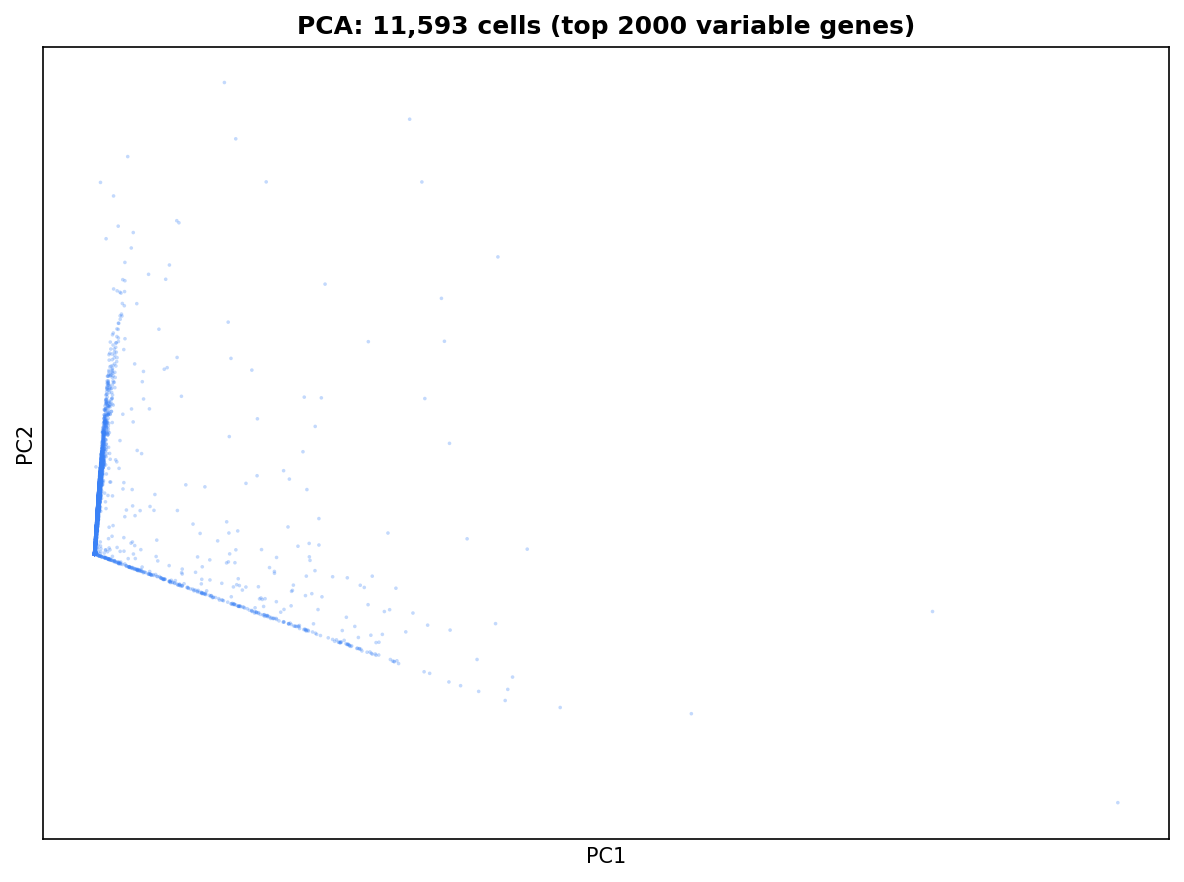

In [7]:
# Cluster composition
cluster_stats = adata.obs.groupby('leiden').agg(
    n_cells=('total_umis', 'count'),
    median_umis=('total_umis', 'median'),
    median_genes=('total_genes', 'median'),
    median_mt=('mt_pct', 'median'),
)
cluster_stats['pct_cells'] = (cluster_stats['n_cells'] / len(adata) * 100).round(1)
print(cluster_stats.to_string())

## Summary

With `singlet.load_dir()`, a singlify pipeline output directory loads directly
into AnnData with all QC metadata pre-attached. From there, standard scanpy
workflows work immediately:

1. **Load**: `singlet.load_dir(path)` → AnnData with genes, barcodes, QC, doublets
2. **Filter**: Remove doublets and low-quality cells using pre-computed metrics
3. **Analyze**: Standard normalize → HVG → PCA → UMAP → Leiden pipeline

No intermediate file conversion needed. The .1pz format reads in seconds even
for 75K+ cell datasets.